# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository. The first three columns denote different parameters obtained from the photographs of the banknotes and last colum provides the label. Frankly as the dataset does not have any description I don't know  which labels corresponds to real and which to counterfeited banknotes. let's assume that label one (positive) denotes the counterfeits. The set  [banknote_authentication.csv](./data/banknote_authentication.csv) can be found in the `data`  directory.

Wykrycie fałszywych banknotów <br>
pierwsze 3 kolumny mówią o parametrach pobranych z banknotu, a ostatnia kolumna to etykieta prawdziwości
<br>
1 - podrobiony
<br>
0 - prawdziwy

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [36]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [37]:
import  matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(8,8)

Please insert you  firstname  and name below

In [38]:
from  sklearn.model_selection import train_test_split
seed = 31287
# Jakub Budzyński

In [39]:
data = pd.read_csv('data/banknotes_data.csv')

In [40]:
data.head()

,a0,a1,a2,a3,counterfeit
0,-1.1306,1.8458,-1.35750,-1.38060,1
1,-1.1188,3.3357,-1.34550,-1.95730,1
2,2.6719,3.0646,0.37158,0.58619,0
3,-4.1409,3.4619,-0.47841,-3.88790,1
4,1.4507,8.7903,-2.23240,-0.65259,0


In [41]:
data.describe()

,a0,a1,a2,a3,counterfeit
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,0.431116,1.902054,1.426607,-1.220393,0.444254
std,2.845672,5.942260,4.397341,2.101777,0.497096
min,-7.042100,-13.773100,-5.286100,-7.871900,0.000000
25%,-1.770900,-1.916200,-1.664300,-2.466150,0.000000
50%,0.471345,2.408650,0.567365,-0.614450,0.000000
75%,2.816925,6.800675,3.338825,0.394810,1.000000
max,6.824800,12.730200,17.927400,2.449500,1.000000


In [42]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a0           1166 non-null   float64
 1   a1           1166 non-null   float64
 2   a2           1166 non-null   float64
 3   a3           1166 non-null   float64
 4   counterfeit  1166 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 45.7 KB


In [43]:
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data.loc[:,'counterfeit'], random_state=seed)
print(data_train[:5])

print(data_train["a0"][:5])

         a0       a1       a2       a3  counterfeit
711  1.9476 -4.77380  8.52700 -1.86680            0
565  1.4276  8.38470 -2.09950 -1.96770            0
912 -4.2859  8.52340  3.13920 -0.91639            0
64   4.9249  0.68906  0.77344  1.20950            0
871  2.1948  1.37810  1.15820  0.85774            0
711    1.9476
565    1.4276
912   -4.2859
64     4.9249
871    2.1948
Name: a0, dtype: float64


In [44]:
data_train

,a0,a1,a2,a3,counterfeit
711,1.94760,-4.773800,8.52700,-1.866800,0
565,1.42760,8.384700,-2.09950,-1.967700,0
912,-4.28590,8.523400,3.13920,-0.916390,0
64,4.92490,0.689060,0.77344,1.209500,0
871,2.19480,1.378100,1.15820,0.857740,0
...,...,...,...,...,...
47,-2.45610,-4.556600,6.45340,-0.056479,1
1161,1.21380,8.798600,-2.16720,-0.741820,0
174,5.87820,5.940900,-2.85440,-0.608630,0
1119,0.17346,7.869500,0.26876,-3.788300,0


In [45]:
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

print(lbls_train)
print("--------------")
print(lbls_test)

711     0
565     0
912     0
64      0
871     0
       ..
47      1
1161    0
174     0
1119    0
1129    1
Name: counterfeit, Length: 932, dtype: int64
--------------
891     0
729     1
687     1
965     1
915     0
       ..
127     0
1046    0
515     1
899     1
1069    1
Name: counterfeit, Length: 234, dtype: int64


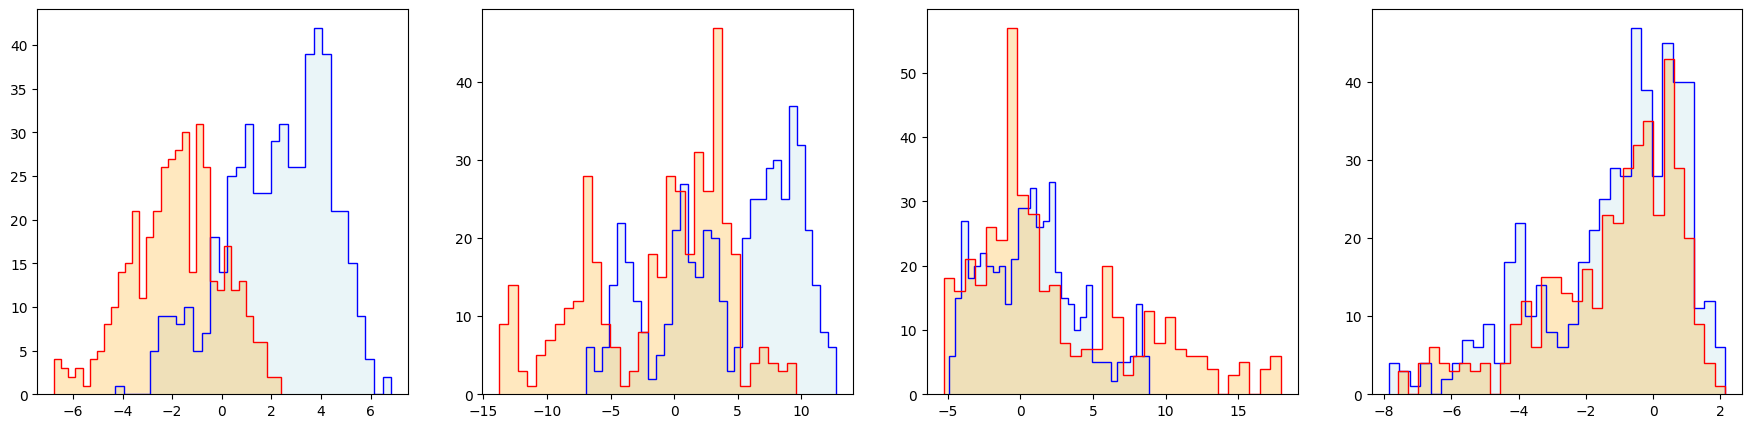

In [46]:
fig, ax = plt.subplots(1,4, figsize=(22,5))
for i in range(4):
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='bar', color='orange', alpha =0.25)

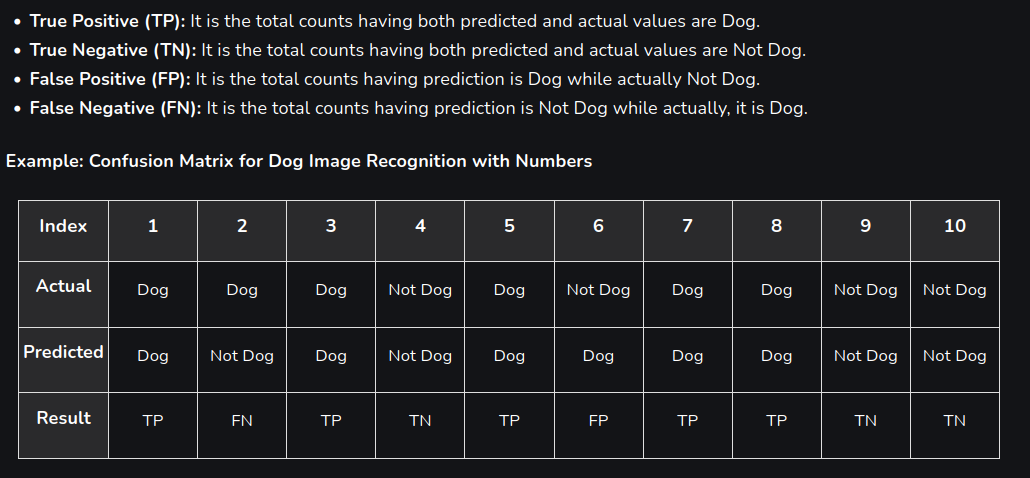

## Problem 1

Using  the [GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html) function construct the  Gaussian  Bayes classifier111 using only one feature. Which feature will you choose? Calculate the confusion matrix (normalized as to show rates), ROC AUC score and plot ROC curve. Do this both for training and validation set. Plot both curves on the same plot.  

Never seen
[[0.87692308 0.12307692]
 [0.18269231 0.81730769]]

Seen
[[0.85328185 0.14671815]
 [0.17149758 0.82850242]]



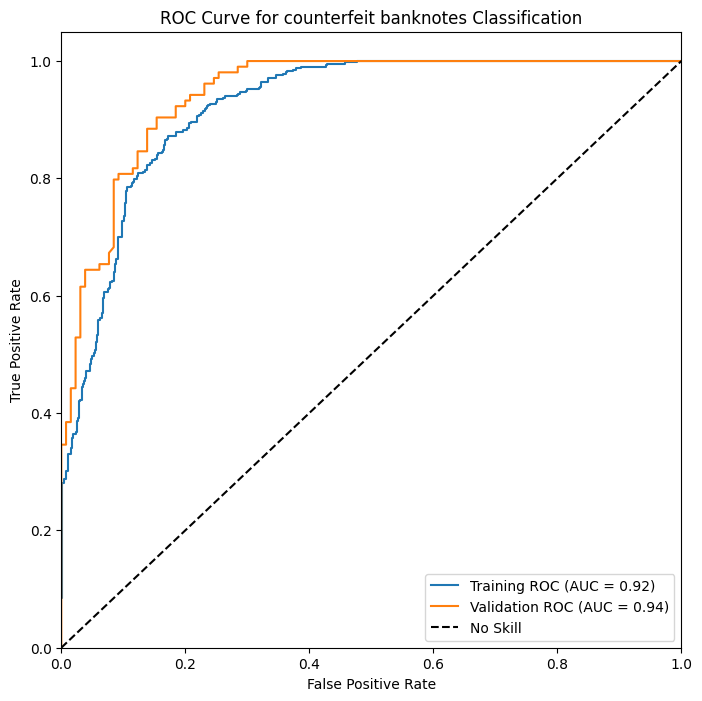

In [47]:
from sklearn.naive_bayes import GaussianNB
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc #area under ROC curve

# CONSTRUCT THE  GAUSSIAN  BAYES classifier1 USING ONLY ONE FEATURE.
classifier1 = GaussianNB()
classifier1.fit(data_train[["a0"]], data_train["counterfeit"])
predicted = classifier1.predict(data_test[["a0"]])
train_pred = classifier1.predict(data_train[["a0"]])

# CONFUSION MATRIX
# True Positive (TP): The model correctly predicted a positive outcome i.e the actual outcome was positive.
# True Negative (TN): The model correctly predicted a negative outcome i.e the actual outcome was negative.
# False Positive (FP): The model incorrectly predicted a positive outcome i.e the actual outcome was negative.
# False Negative (FN): The model incorrectly predicted a negative outcome i.e the actual outcome was positive.


# CONFUSION MATRIX
cm = confusion_matrix(data_test[["counterfeit"]],predicted, normalize='true')
print("Never seen")
print(cm)
print()

cm = confusion_matrix(data_train[["counterfeit"]],train_pred, normalize='true')
print("Seen")
print(cm)
print()


# ROC AUC

train_prob = classifier1.predict_proba(data_train[["a0"]])[:, 1] # predict probability
test_prob = classifier1.predict_proba(data_test[["a0"]])[:, 1]

fpr_train, tpr_train, thresholds_train = roc_curve(data_train[["counterfeit"]], train_prob) 
auc_train = auc(fpr_train, tpr_train)
fpr_test, tpr_test, thresholds_test = roc_curve(data_test[["counterfeit"]], test_prob) 
auc_test = auc(fpr_test, tpr_test)
plt.figure()  

plt.plot(
    fpr_train,
    tpr_train,
    label=f"Training ROC (AUC = {auc_train:.2f})"
)

plt.plot(
    fpr_test,
    tpr_test,
    label=f"Validation ROC (AUC = {auc_test:.2f})"
)


plt.plot([0, 1], [0, 1], 'k--', label='No Skill') #Random quesing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for counterfeit banknotes Classification')
plt.legend()
plt.show()







## Problem 2

Same as Problem 1 but now construct Gaussian Naive Bayes using two features. Additionally  compare ROC curve obtained with this and previous  classifier on the test set. What is the improvement of AUC score on the test set?

Never seen
[[0.90769231 0.09230769]
 [0.16346154 0.83653846]]

Seen
[[0.8957529  0.1042471 ]
 [0.16666667 0.83333333]]



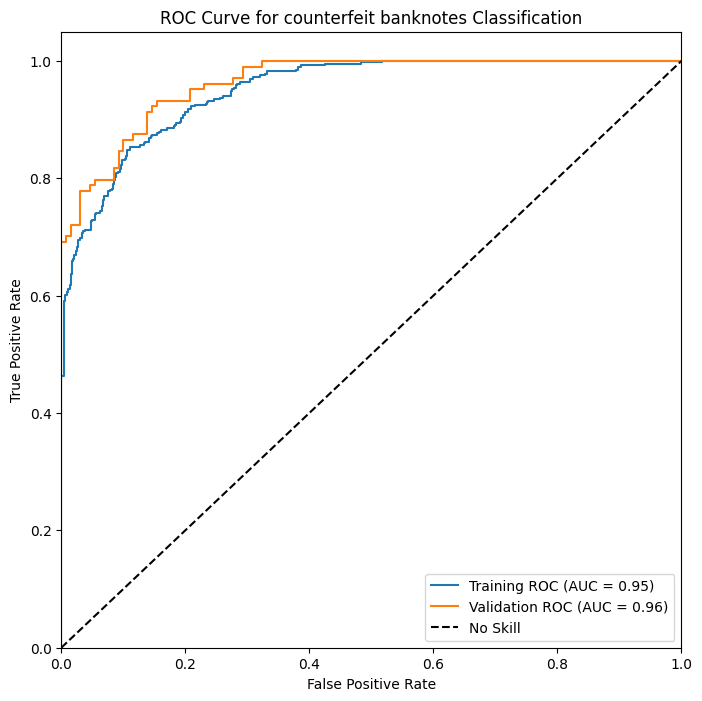

Conclusion: second feature improves model quality. Model has more specific data to train


In [48]:
from sklearn.naive_bayes import GaussianNB
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc #area under ROC curve

# CONSTRUCT THE  GAUSSIAN  BAYES CLASSIFIER USING ONLY TWO FEATURES.
classifier2 = GaussianNB()
classifier2.fit(data_train[["a0", "a1"]], data_train["counterfeit"])
predicted = classifier2.predict(data_test[["a0", "a1"]])
train_pred = classifier2.predict(data_train[["a0", "a1"]])



# CONFUSION MATRIX
cm = confusion_matrix(data_test[["counterfeit"]],predicted, normalize='true')
print("Never seen")
print(cm)
print()

cm = confusion_matrix(data_train[["counterfeit"]],train_pred, normalize='true')
print("Seen")
print(cm)
print()


# ROC AUC

train_prob = classifier2.predict_proba(data_train[["a0", "a1"]])[:, 1] # predict probability
test_prob = classifier2.predict_proba(data_test[["a0", "a1"]])[:, 1]

fpr_train, tpr_train, thresholds_train = roc_curve(data_train[["counterfeit"]], train_prob) 
auc_train = auc(fpr_train, tpr_train)
fpr_test, tpr_test, thresholds_test = roc_curve(data_test[["counterfeit"]], test_prob) 
auc_test = auc(fpr_test, tpr_test)
plt.figure()  

plt.plot(
    fpr_train,
    tpr_train,
    label=f"Training ROC (AUC = {auc_train:.2f})"
)

plt.plot(
    fpr_test,
    tpr_test,
    label=f"Validation ROC (AUC = {auc_test:.2f})"
)


plt.plot([0, 1], [0, 1], 'k--', label='No Skill') #Random quesing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for counterfeit banknotes Classification')
plt.legend()
plt.show()


print("Conclusion: second feature improves model quality. Model has more specific data to train")







## Problem 3

Never seen
[[0.89230769 0.10769231]
 [0.20192308 0.79807692]]



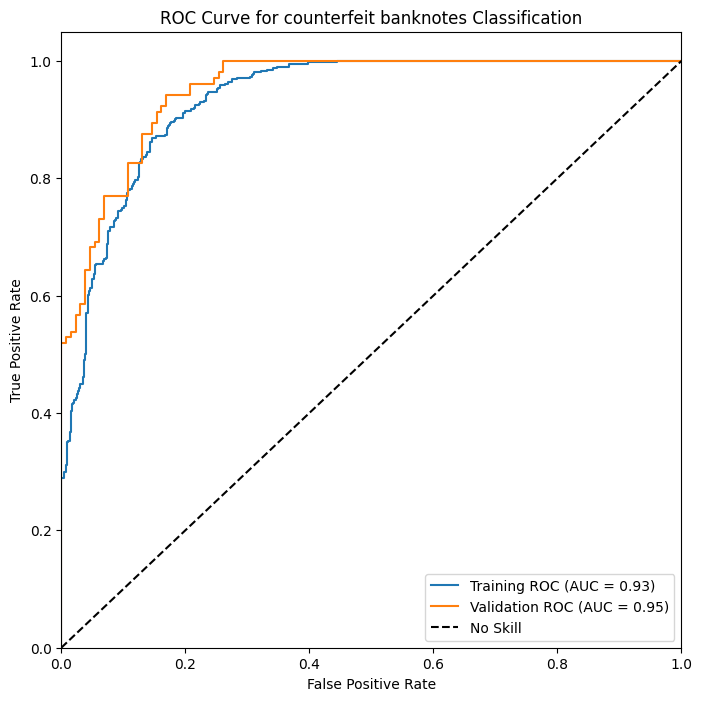

In [57]:
from sklearn.naive_bayes import GaussianNB
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc #area under ROC curve
import math

# CONSTRUCT THE  GAUSSIAN  BAYES CLASSIFIER USING ALL FEATURES.
classifier3 = GaussianNB()
classifier3.fit(data_train[["a0", "a1", "a2", "a3"]], data_train["counterfeit"])
predicted = classifier3.predict(data_test[["a0", "a1", "a2", "a3"]])
train_pred = classifier3.predict(data_train[["a0", "a1", "a2", "a3"]])



# CONFUSION MATRIX FOR TEST SET
cm = confusion_matrix(data_test[["counterfeit"]],predicted, normalize='true')
print("Never seen")
print(cm)
print()



# ROC AUC

train_prob = classifier3.predict_proba(data_train[["a0", "a1", "a2", "a3"]])[:, 1] # predict probability
test_prob = classifier3.predict_proba(data_test[["a0", "a1", "a2", "a3"]])[:, 1]

fpr_train, tpr_train, thresholds_train = roc_curve(data_train[["counterfeit"]], train_prob) 
auc_train = auc(fpr_train, tpr_train)
fpr_test, tpr_test, thresholds_test = roc_curve(data_test[["counterfeit"]], test_prob) 
auc_test = auc(fpr_test, tpr_test)
plt.figure()  

plt.plot(
    fpr_train,
    tpr_train,
    label=f"Training ROC (AUC = {auc_train:.2f})"
)

plt.plot(
    fpr_test,
    tpr_test,
    label=f"Validation ROC (AUC = {auc_test:.2f})"
)


plt.plot([0, 1], [0, 1], 'k--', label='No Skill') #Random quesing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for counterfeit banknotes Classification')
plt.legend()
plt.show()






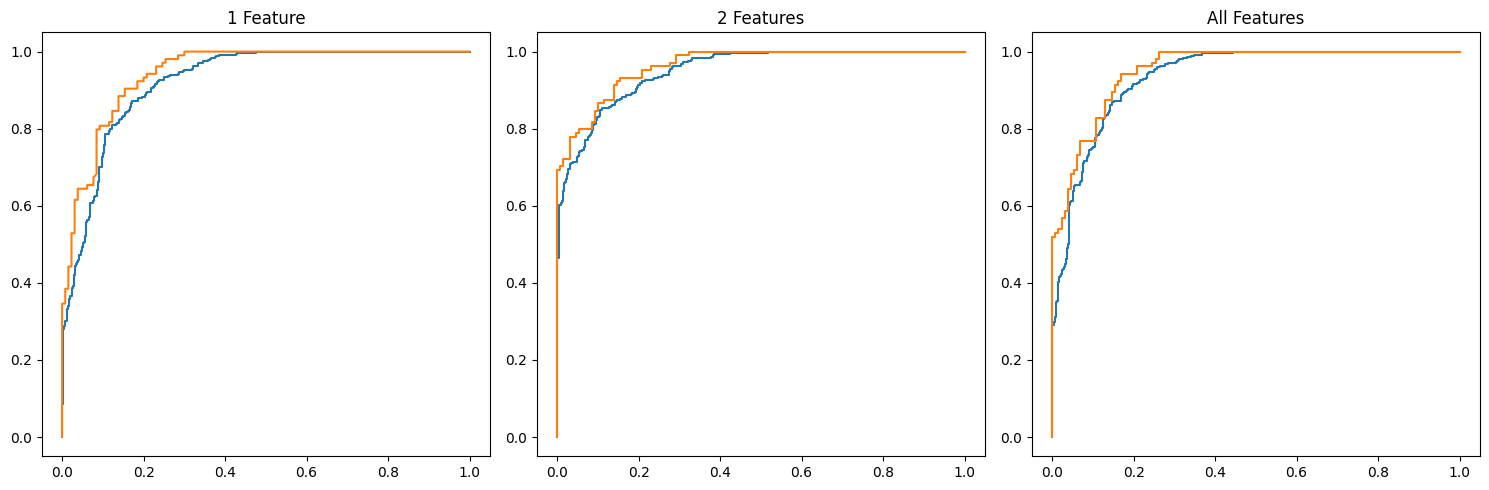

The second seems the best  (੭˶´◕ω⁠◕`˶)੭


In [59]:
# COMPARE ALL 3

# All Features
train_prob_all = classifier3.predict_proba(data_train[["a0", "a1", "a2", "a3"]])[:, 1]
test_prob_all = classifier3.predict_proba(data_test[["a0", "a1", "a2", "a3"]])[:, 1]

fpr_train_all, tpr_train_all, thresholds_train_all = roc_curve(data_train[["counterfeit"]], train_prob_all) 
auc_train_all = auc(fpr_train_all, tpr_train_all)
fpr_test_all, tpr_test_all, thresholds_test_all = roc_curve(data_test[["counterfeit"]], test_prob_all) 
auc_test_all = auc(fpr_test_all, tpr_test_all)

# 1 Feature
train_prob_1 = classifier1.predict_proba(data_train[["a0"]])[:, 1]
test_prob_1 = classifier1.predict_proba(data_test[["a0"]])[:, 1]

fpr_train_1, tpr_train_1, thresholds_train_1 = roc_curve(data_train[["counterfeit"]], train_prob_1) 
auc_train_1 = auc(fpr_train_1, tpr_train_1)
fpr_test_1, tpr_test_1, thresholds_test_1 = roc_curve(data_test[["counterfeit"]], test_prob_1) 
auc_test_1 = auc(fpr_test_all, tpr_test_all)

# 2 Feature
train_prob_2 = classifier2.predict_proba(data_train[["a0", "a1"]])[:, 1]
test_prob_2 = classifier2.predict_proba(data_test[["a0", "a1"]])[:, 1]

fpr_train_2, tpr_train_2, thresholds_train_2 = roc_curve(data_train[["counterfeit"]], train_prob_2) 
auc_train_2 = auc(fpr_train_2, tpr_train_2)
fpr_test_2, tpr_test_2, thresholds_test_2 = roc_curve(data_test[["counterfeit"]], test_prob_2) 
auc_test_2 = auc(fpr_test_2, tpr_test_2)


fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].plot(fpr_train_1, tpr_train_1)
axs[0].plot(fpr_test_1, tpr_test_1)
axs[0].set_title("1 Feature")

axs[1].plot(fpr_train_2, tpr_train_2)
axs[1].plot(fpr_test_2, tpr_test_2)
axs[1].set_title("2 Features")

axs[2].plot(fpr_train_all, tpr_train_all)
axs[2].plot(fpr_test_all, tpr_test_all)
axs[2].set_title("All Features")

plt.tight_layout()
plt.show()

print("The second seems the best  (੭˶´◕ω⁠◕`˶)੭")

